In [ ]:
import os
import torch
import matplotlib.pyplot as plt

from src.concaves.log import LogConcave

from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism
from src.diffeomorphisms.vector.concave import ConcaveVectorDiffeomorphism

from src.distributions.starflows.r2.river_cross import RiverCrossStarFlowDistribution

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean

# results folder
results_folder = os.path.join("results", "river_cross")
os.makedirs(results_folder, exist_ok=True)

# set random seed
torch.manual_seed(31)

In [6]:
star_flow = RiverCrossStarFlowDistribution()

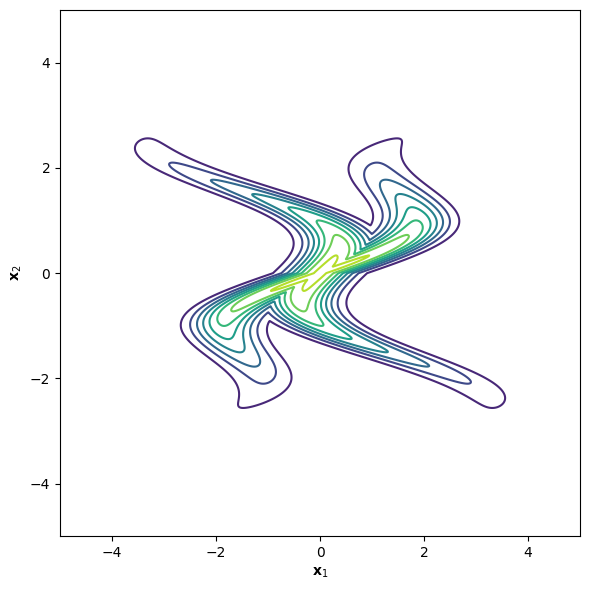

In [7]:
n_points = 1001
x = torch.linspace(-7, 7, n_points)
y = torch.linspace(-7, 7, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs_multi = torch.exp(star_flow.log_prob(XY).reshape(n_points, n_points).detach())


# plot samples
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis')
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "log_probs_starflow.png"))
plt.show()

In [8]:
phi = StarFlowVectorDiffeomorphism(2, star_flow)
psi = ConcaveVectorDiffeomorphism(2, LogConcave(a=10.))
Phi = CompositionDiffeomorphism([phi, psi])
phi_manifold = StandardPullbackVectorEuclidean(phi)
Phi_manifold = StandardPullbackVectorEuclidean(Phi)

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_23351/4155421867.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


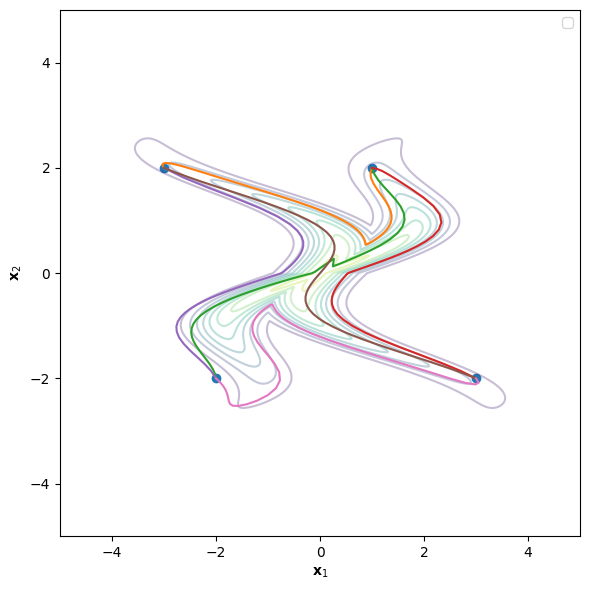

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_23351/4155421867.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


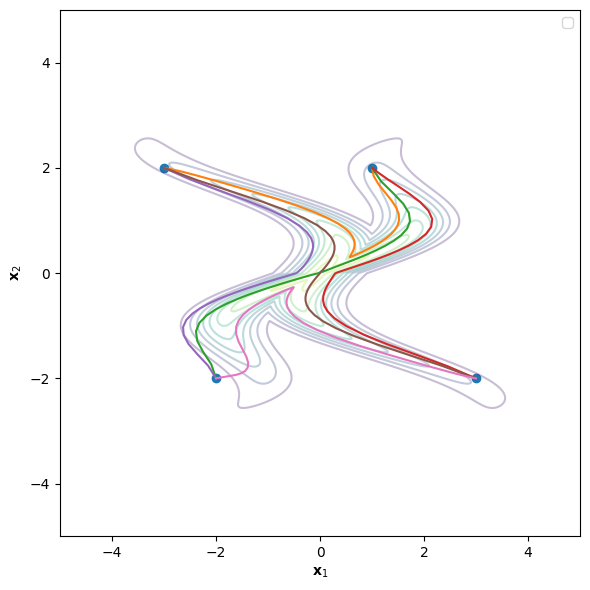

In [9]:
t = torch.linspace(0, 1, 50)

data = torch.tensor([[1., 2.], [-3., 2.], [-2., -2.], [3., -2]])

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

k=1
for i in range(4):
    for j in range(i+1, 4):
        x_i = data[i]
        x_j = data[j]
        # interpolate between cluster centers
        phi_geodesics = phi_manifold.geodesic(x_i[None,None], x_j[None,None], t)[0,0,0]
        plt.plot(phi_geodesics[:, 0].numpy(), phi_geodesics[:, 1].numpy(), color=plt.cm.tab10(k))
        k += 1

plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), color=plt.cm.tab10(0), marker='o')
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.legend()
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_starflow.png"))
plt.show()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

k=1
for i in range(4):
    for j in range(i+1, 4):
        mu_i = data[i]
        mu_j = data[j]
        # interpolate between cluster centers
        Phi_geodesics = Phi_manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(Phi_geodesics[:, 0].numpy(), Phi_geodesics[:, 1].numpy(), color=plt.cm.tab10(k))
        k += 1

plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), color=plt.cm.tab10(0), marker='o')
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.legend()
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_conv_starflow.png"))
plt.show()